In [1]:
!pip install xgboost imbalanced-learn scikit-optimize

print("✅ xgboost installed")
print("✅ imbalanced-learn installed")
print("✅ scikit-optimize installed")
print("✅ Ready to proceed!")

✅ xgboost installed
✅ imbalanced-learn installed
✅ scikit-optimize installed
✅ Ready to proceed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
df = pd.read_csv(
    "../../research/datasets/delay-cases/delay_data.csv"
)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDelay Risk Distribution:")
print(df["delay_risk"].value_counts())
df.head()

Shape: (192, 15)

Columns: ['phase_group', 'sub_phase', 'district', 'province', 'floors', 'delay_category', 'labour_availability', 'material_supply', 'weather_severity', 'cumulative_delay', 'delay_risk', 'delay_days', 'cause_of_delay', 'corrective_action_taken', 'construction_status']

Delay Risk Distribution:
delay_risk
MEDIUM    103
HIGH       60
LOW        29
Name: count, dtype: int64


,phase_group,sub_phase,district,province,floors,delay_category,labour_availability,material_supply,weather_severity,cumulative_delay,delay_risk,delay_days,cause_of_delay,corrective_action_taken,construction_status
0,Structure,Floor slabs,Kilinochchi,Northern Province,2,Financial & Funding,0.70,1,0.30,44,HIGH,90,NHDA resettlement grant released in instalment...,Work phased carefully to match NHDA grant inst...,Completed in phased approach
1,Structure,Floor slabs,Matara,Southern Province,2,Financial & Funding,0.88,1,0.26,19,HIGH,180,Construction costs exceeded budget due to 2022...,Phased construction approach adopted to manage...,Partially completed - roof level only
2,Pre-Construction & Approvals,BOQ preparation & tendering,Trincomalee,Eastern Province,1,Owner / Social / Behavioural,0.60,1,0.41,10,MEDIUM,45,Diaspora Trincomalee owner abroad unable to ma...,Power of attorney given to local relative to m...,Completed after governance change
3,Envelope & Waterproofing,External rendering,Matara,Southern Province,1,Environmental & Site,0.80,1,0.77,59,HIGH,55,Coastal erosion near Matara beach site threate...,Retaining wall and rock armouring constructed ...,Completed with coastal protection measures
4,Structure,Columns & beams,Ampara,Eastern Province,1,Material Supply & Quality,0.83,0,0.36,44,HIGH,120,Cement and steel unavailable in Ampara during ...,Bulk materials procured from Colombo at additi...,Completed with significant cost overrun


In [4]:
print("Null values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Null values:
phase_group                0
sub_phase                  0
district                   0
province                   0
floors                     0
delay_category             0
labour_availability        0
material_supply            0
weather_severity           0
cumulative_delay           0
delay_risk                 0
delay_days                 0
cause_of_delay             0
corrective_action_taken    0
construction_status        0
dtype: int64

Data Types:
phase_group                 object
sub_phase                   object
district                    object
province                    object
floors                       int64
delay_category              object
labour_availability        float64
material_supply              int64
weather_severity           float64
cumulative_delay             int64
delay_risk                  object
delay_days                   int64
cause_of_delay              object
corrective_action_taken     object
construction_status         object
d

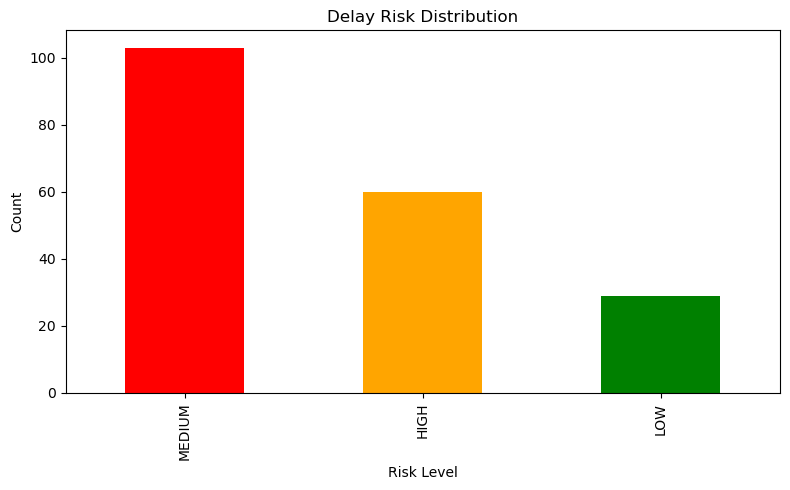

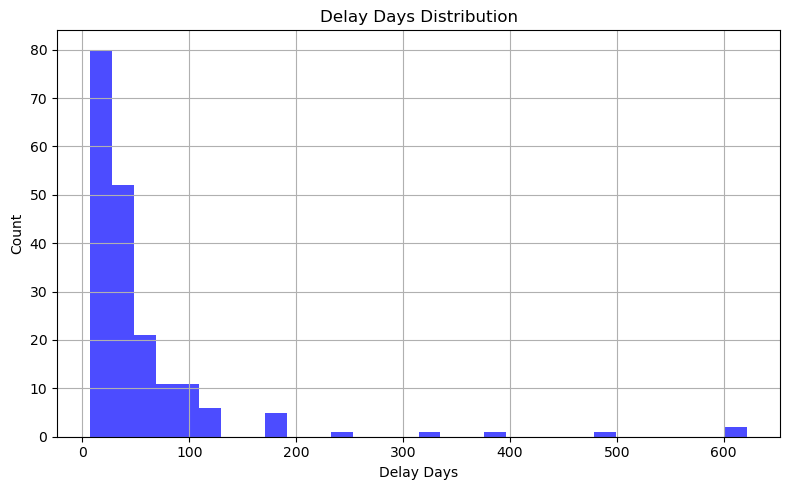

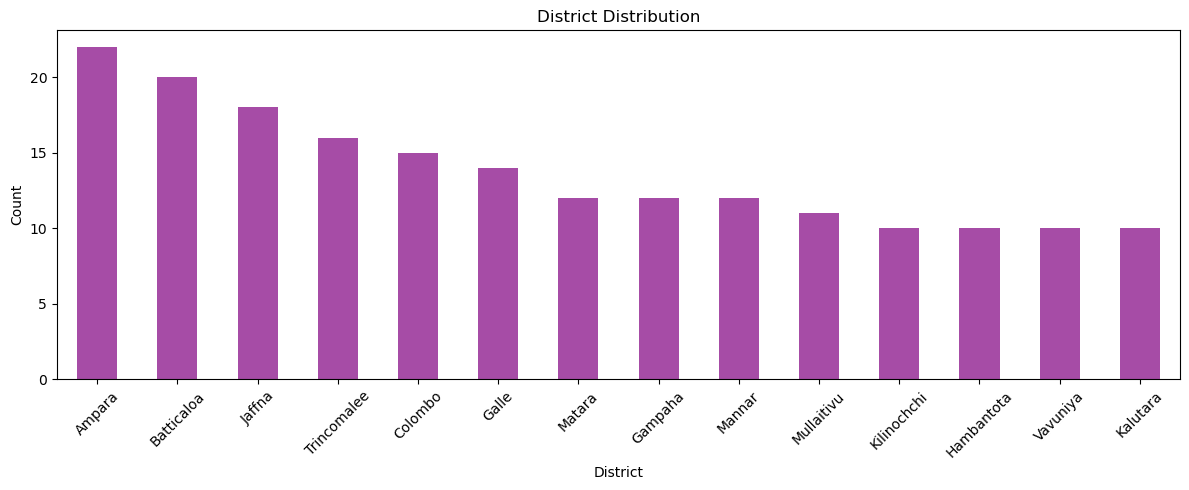

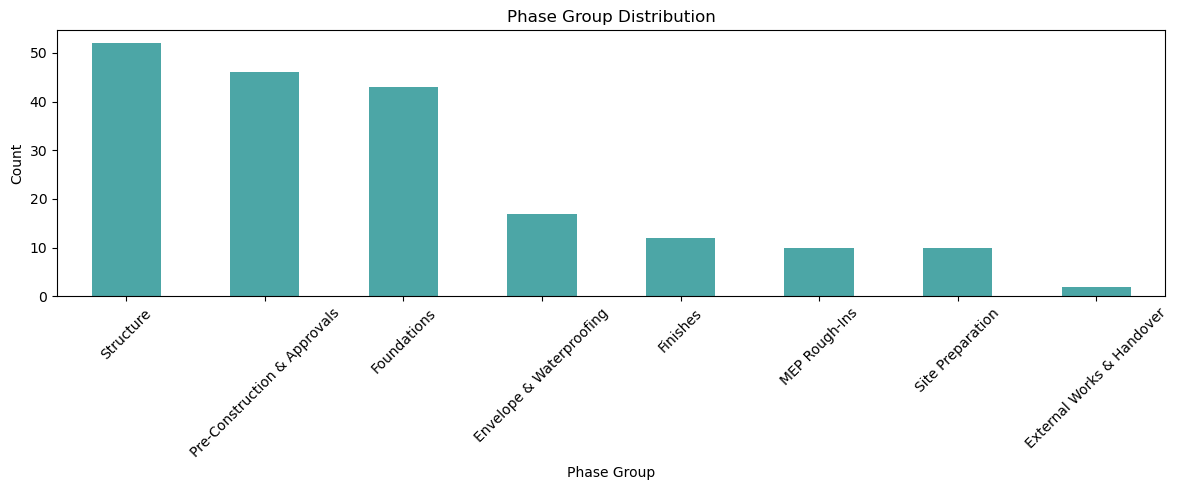

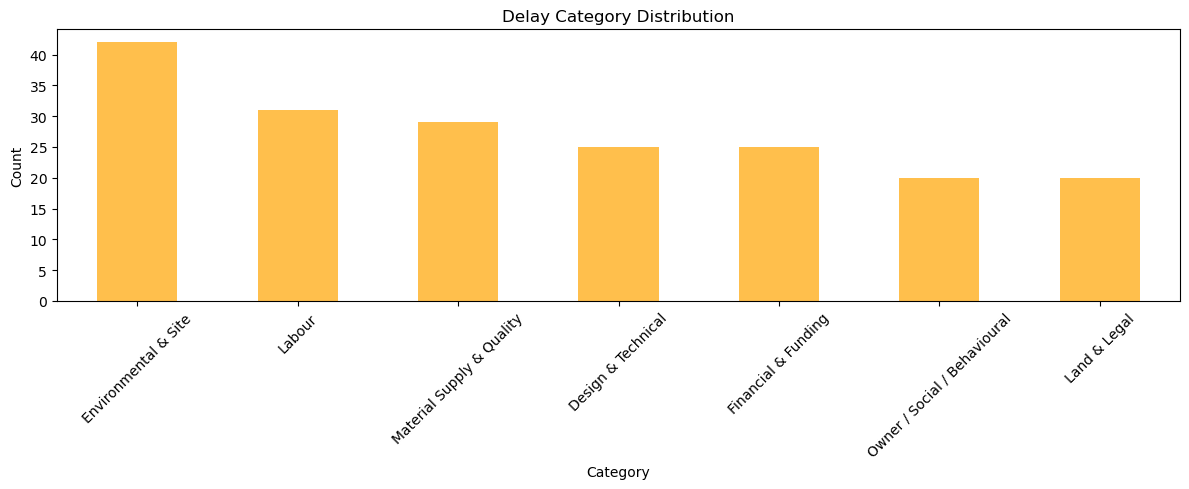

In [5]:
# Delay risk distribution
plt.figure(figsize=(8,5))
df["delay_risk"].value_counts().plot(
    kind="bar",
    color=["red","orange","green"]
)
plt.title("Delay Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Delay days distribution
plt.figure(figsize=(8,5))
df["delay_days"].hist(
    bins=30, color="blue", alpha=0.7)
plt.title("Delay Days Distribution")
plt.xlabel("Delay Days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# District distribution
plt.figure(figsize=(12,5))
df["district"].value_counts().plot(
    kind="bar", color="purple", alpha=0.7)
plt.title("District Distribution")
plt.xlabel("District")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Phase group distribution
plt.figure(figsize=(12,5))
df["phase_group"].value_counts().plot(
    kind="bar", color="teal", alpha=0.7)
plt.title("Phase Group Distribution")
plt.xlabel("Phase Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Delay category distribution
plt.figure(figsize=(12,5))
df["delay_category"].value_counts().plot(
    kind="bar", color="orange", alpha=0.7)
plt.title("Delay Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
feature_cols = [
    "phase_group",
    "sub_phase",
    "district",
    "province",
    "floors",
    "delay_category",
    "labour_availability",
    "material_supply",
    "weather_severity",
    "cumulative_delay"
]

target_class = "delay_risk"
target_reg   = "delay_days"

df = df.dropna(subset=feature_cols +
               [target_class, target_reg])

print("Clean data shape:", df.shape)
print("Features:", feature_cols)

Clean data shape: (192, 15)
Features: ['phase_group', 'sub_phase', 'district', 'province', 'floors', 'delay_category', 'labour_availability', 'material_supply', 'weather_severity', 'cumulative_delay']


In [7]:
encoders = {}

le_phase_group = LabelEncoder()
df["phase_group"] = le_phase_group.fit_transform(
    df["phase_group"])
encoders["phase_group"] = le_phase_group

le_sub_phase = LabelEncoder()
df["sub_phase"] = le_sub_phase.fit_transform(
    df["sub_phase"])
encoders["sub_phase"] = le_sub_phase

le_district = LabelEncoder()
df["district"] = le_district.fit_transform(
    df["district"])
encoders["district"] = le_district

le_province = LabelEncoder()
df["province"] = le_province.fit_transform(
    df["province"])
encoders["province"] = le_province

le_delay_cat = LabelEncoder()
df["delay_category"] = le_delay_cat.fit_transform(
    df["delay_category"])
encoders["delay_category"] = le_delay_cat

le_risk = LabelEncoder()
df["delay_risk"] = le_risk.fit_transform(
    df["delay_risk"])
encoders["delay_risk"] = le_risk

print("Phase groups:   ", le_phase_group.classes_)
print("Sub phases:     ", le_sub_phase.classes_)
print("Districts:      ", le_district.classes_)
print("Provinces:      ", le_province.classes_)
print("Delay cats:     ", le_delay_cat.classes_)
print("Risk classes:   ", le_risk.classes_)
print("✅ Encoding done")

Phase groups:    ['Envelope & Waterproofing' 'External Works & Handover' 'Finishes'
 'Foundations' 'MEP Rough-Ins' 'Pre-Construction & Approvals'
 'Site Preparation' 'Structure']
Sub phases:      ['Architectural & structural design' 'Authority approvals'
 'BOQ preparation & tendering' 'Boundary wall & gate'
 'Carpentry & joinery' 'Columns & beams' 'Earthworks & grading'
 'Electrical conduit work' 'External rendering' 'Floor slabs'
 'Foundation work' 'Ground beams' 'Ground floor slab'
 'Internal plastering' 'Masonry work' 'Plumbing & drainage' 'Roof slab'
 'Roof waterproofing' 'Site clearing & hoarding'
 'Site selection & surveying' 'Snagging & rectification'
 'Soil investigation' 'Tiling']
Districts:       ['Ampara' 'Batticaloa' 'Colombo' 'Galle' 'Gampaha' 'Hambantota' 'Jaffna'
 'Kalutara' 'Kilinochchi' 'Mannar' 'Matara' 'Mullaitivu' 'Trincomalee'
 'Vavuniya']
Provinces:       ['Eastern Province' 'Northern Province' 'Southern Province'
 'Western Province']
Delay cats:      ['Design & T

In [8]:
X = df[feature_cols]
y_class = df[target_class]
y_reg   = df[target_reg]

X_train, X_test, \
y_class_train, y_class_test, \
y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain class distribution:")
print(pd.Series(y_class_train).value_counts())
print("\nTest class distribution:")
print(pd.Series(y_class_test).value_counts())

Train size: (153, 10)
Test size:  (39, 10)

Train class distribution:
delay_risk
2    82
0    48
1    23
Name: count, dtype: int64

Test class distribution:
delay_risk
2    21
0    12
1     6
Name: count, dtype: int64


In [9]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(
    X_train, y_class_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE: ", X_train_sm.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE: (153, 10)
After SMOTE:  (246, 10)

Class distribution after SMOTE:
delay_risk
2    82
0    82
1    82
Name: count, dtype: int64


In [10]:
search_space = {
    "n_estimators":     Integer(100, 500),
    "max_depth":        Integer(3, 10),
    "learning_rate":    Real(0.01, 0.3),
    "subsample":        Real(0.6, 1.0),
    "colsample_bytree": Real(0.6, 1.0),
    "min_child_weight": Integer(1, 10)
}

bayes_search = BayesSearchCV(
    XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ),
    search_spaces=search_space,
    n_iter=8,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

bayes_search.fit(X_train_sm, y_train_sm)

print("\n✅ Bayesian Optimization done!")
print("Best Parameters:")
print(bayes_search.best_params_)
print("Best CV F1 Score:",
    round(bayes_search.best_score_, 4))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Bayesian Optimization done!
Best Parameters:
OrderedDict({'colsample_bytree': 0.7779330049204607, 'learning_rate': 0.27642953128411935, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 175, 'subsample': 0.7814661375225196})
Best CV F1 Score: 0.9347


In [11]:
best_params = bayes_search.best_params_

classifier = XGBClassifier(
    **best_params,
    eval_metric="mlogloss",
    random_state=42
)

classifier.fit(X_train_sm, y_train_sm)
print("✅ Classifier trained with best params!")
print("Parameters:", best_params)

✅ Classifier trained with best params!
Parameters: OrderedDict({'colsample_bytree': 0.7779330049204607, 'learning_rate': 0.27642953128411935, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 175, 'subsample': 0.7814661375225196})


Accuracy: 0.8718
F1 Score: 0.8716

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.91      0.83      0.87        12
         LOW       0.83      0.83      0.83         6
      MEDIUM       0.86      0.90      0.88        21

    accuracy                           0.87        39
   macro avg       0.87      0.86      0.86        39
weighted avg       0.87      0.87      0.87        39



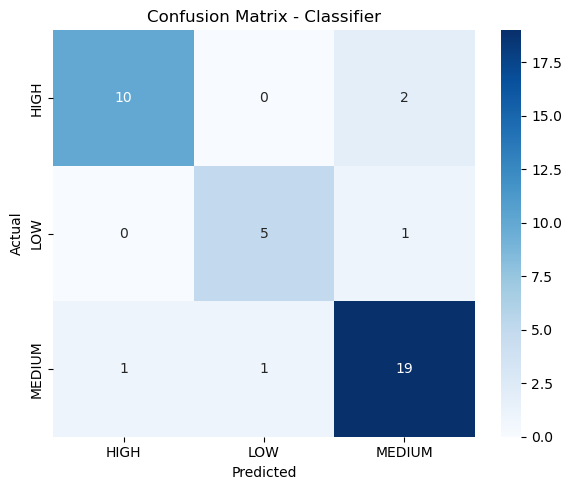

In [12]:
y_pred_class = classifier.predict(X_test)

print("Accuracy:",
    round(accuracy_score(
        y_class_test, y_pred_class), 4))
print("F1 Score:",
    round(f1_score(
        y_class_test, y_pred_class,
        average="weighted"), 4))
print("\nClassification Report:")
print(classification_report(
    y_class_test, y_pred_class,
    target_names=le_risk.classes_))

plt.figure(figsize=(6,5))
cm = confusion_matrix(
    y_class_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d",
    xticklabels=le_risk.classes_,
    yticklabels=le_risk.classes_,
    cmap="Blues")
plt.title("Confusion Matrix - Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [13]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

cv_scores = cross_val_score(
    classifier,
    X_train_sm, y_train_sm,
    cv=kfold,
    scoring="f1_weighted"
)

print("K-Fold CV Results (k=5):")
print("Fold scores:",
    [round(s, 4) for s in cv_scores])
print(f"Mean F1:  {cv_scores.mean():.4f}")
print(f"Std F1:   {cv_scores.std():.4f}")

K-Fold CV Results (k=5):
Fold scores: [np.float64(0.9386), np.float64(0.9585), np.float64(0.9591), np.float64(0.8776), np.float64(0.9382)]
Mean F1:  0.9344
Std F1:   0.0299


In [14]:
regressor = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

regressor.fit(X_train, y_reg_train)
print("✅ Regressor trained!")

✅ Regressor trained!


MAE:  29.69 days
RMSE: 68.34 days


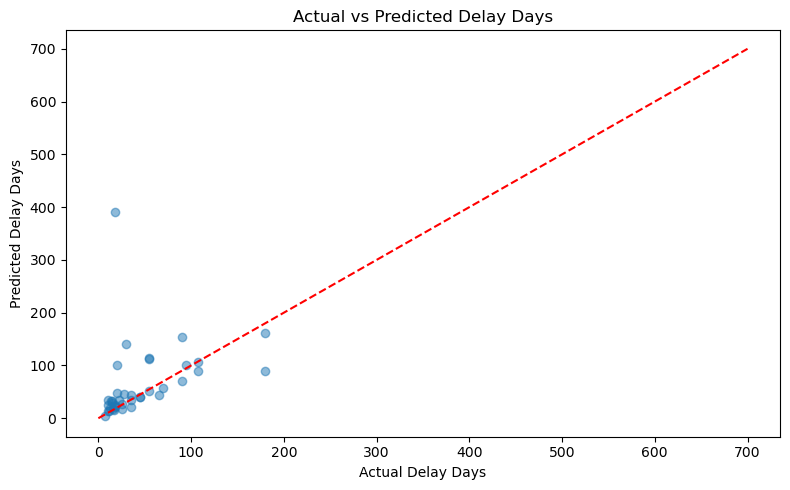

In [15]:
y_pred_reg = regressor.predict(X_test)

mae  = mean_absolute_error(
    y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(
    y_reg_test, y_pred_reg))

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")

plt.figure(figsize=(8,5))
plt.scatter(
    y_reg_test, y_pred_reg, alpha=0.5)
plt.plot([0,700],[0,700],"r--")
plt.xlabel("Actual Delay Days")
plt.ylabel("Predicted Delay Days")
plt.title("Actual vs Predicted Delay Days")
plt.tight_layout()
plt.show()

In [16]:
os.makedirs(
    "../../performance/models",
    exist_ok=True)

classifier.save_model(
    "../../performance/models/xgboost_classifier.json")

regressor.save_model(
    "../../performance/models/xgboost_regressor.json")

with open(
    "../../performance/models/label_encoders.pkl",
    "wb") as f:
    pickle.dump(encoders, f)

print("✅ Classifier saved")
print("✅ Regressor saved")
print("✅ Encoders saved")

✅ Classifier saved
✅ Regressor saved
✅ Encoders saved


In [17]:
sample = pd.DataFrame([{
    "phase_group":
        le_phase_group.transform(["Foundations"])[0],
    "sub_phase":
        le_sub_phase.transform(["Foundation work"])[0],
    "district":
        le_district.transform(["Jaffna"])[0],
    "province":
        le_province.transform(["Northern Province"])[0],
    "floors": 2,
    "delay_category":
        le_delay_cat.transform(["Labour"])[0],
    "labour_availability": 0.30,
    "material_supply": 1,
    "weather_severity": 0.75,
    "cumulative_delay": 20
}])

risk_encoded  = classifier.predict(sample)
risk_proba    = classifier.predict_proba(sample)
days          = regressor.predict(sample)
risk_label    = le_risk.inverse_transform(
    risk_encoded)[0]
confidence    = round(float(
    risk_proba.max()) * 100, 2)

print("━━━━━━━━━━━━━━━━━━━━━━━")
print("  Test Prediction Result")
print("━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Risk:       {risk_label}")
print(f"  Days:       {round(float(days[0]),1)}")
print(f"  Confidence: {confidence}%")
print("━━━━━━━━━━━━━━━━━━━━━━━")

━━━━━━━━━━━━━━━━━━━━━━━
  Test Prediction Result
━━━━━━━━━━━━━━━━━━━━━━━
  Risk:       MEDIUM
  Days:       27.4
  Confidence: 86.45%
━━━━━━━━━━━━━━━━━━━━━━━


In [18]:
sample = pd.DataFrame([{
    "phase_group":
        le_phase_group.transform(["Foundations"])[0],
    "sub_phase":
        le_sub_phase.transform(["Foundation work"])[0],
    "district":
        le_district.transform(["Vavuniya"])[0],
    "province":
        le_province.transform(["Northern Province"])[0],
    "floors": 2,
    "delay_category":
        le_delay_cat.transform(["Labour"])[0],
    "labour_availability": 0.30,
    "material_supply": 1,
    "weather_severity": 0.75,
    "cumulative_delay": 20
}])

risk_encoded  = classifier.predict(sample)
risk_proba    = classifier.predict_proba(sample)
days          = regressor.predict(sample)
risk_label    = le_risk.inverse_transform(
    risk_encoded)[0]
confidence    = round(float(
    risk_proba.max()) * 100, 2)

print("━━━━━━━━━━━━━━━━━━━━━━━")
print("  Test Prediction Result")
print("━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Risk:       {risk_label}")
print(f"  Days:       {round(float(days[0]),1)}")
print(f"  Confidence: {confidence}%")
print("━━━━━━━━━━━━━━━━━━━━━━━")

━━━━━━━━━━━━━━━━━━━━━━━
  Test Prediction Result
━━━━━━━━━━━━━━━━━━━━━━━
  Risk:       MEDIUM
  Days:       38.1
  Confidence: 87.67%
━━━━━━━━━━━━━━━━━━━━━━━
